In [11]:
# ============================================================
# Hospital Patient Readmission Analysis
# Step 1: Data Loading & Initial Exploration
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('../data/raw/diabetic_data.csv')

# ---- Basic Overview ----
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())

Shape: (101766, 50)

Column Names:
 ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Data Types:
 encounter_id                int64
patient_nbr                 int64
race                          str
gender                        

In [12]:
# ============================================================
# Phase 2: Missing Values & Target Variable Analysis
# ============================================================

# --- Replace '?' with NaN across the entire dataframe ---
df.replace('?', np.nan, inplace=True)

# --- Check missing values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print("=== Columns with Missing Values ===")
print(missing_df)

# --- Target Variable Distribution ---
print("\n=== Target Variable: readmitted ===")
print(df['readmitted'].value_counts())
print(df['readmitted'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# --- Shape after replacing ? ---
print("\nDataset shape:", df.shape)

=== Columns with Missing Values ===
                   Missing Count  Missing %
weight                     98569      96.86
max_glu_serum              96420      94.75
A1Cresult                  84748      83.28
medical_specialty          49949      49.08
payer_code                 40256      39.56
race                        2273       2.23
diag_3                      1423       1.40
diag_2                       358       0.35
diag_1                        21       0.02

=== Target Variable: readmitted ===
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64
readmitted
NO     53.91%
>30    34.93%
<30    11.16%
Name: proportion, dtype: str

Dataset shape: (101766, 50)


In [13]:
# ============================================================
# Phase 3: Data Cleaning
# ============================================================

# --- Drop high-missing & irrelevant columns ---
cols_to_drop = ['weight', 'max_glu_serum', 'A1Cresult', 
                'medical_specialty', 'payer_code',
                'encounter_id', 'patient_nbr']  # IDs are not features

df.drop(columns=cols_to_drop, inplace=True)

# --- Fill remaining missing values ---
df['race'].fillna(df['race'].mode()[0], inplace=True)
df['diag_1'].fillna('Unknown', inplace=True)
df['diag_2'].fillna('Unknown', inplace=True)
df['diag_3'].fillna('Unknown', inplace=True)

# --- Confirm no missing values remain ---
print("Remaining missing values:", df.isnull().sum().sum())

# --- Convert age ranges to numeric midpoints ---
age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65,
    '[70-80)': 75, '[80-90)': 85, '[90-100)': 95
}
df['age'] = df['age'].map(age_map)

# --- Create binary target variable ---
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

print("\nReadmission class distribution (binary):")
print(df['readmitted_binary'].value_counts())
print("\nCleaned dataset shape:", df.shape)

Remaining missing values: 4075

Readmission class distribution (binary):
readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

Cleaned dataset shape: (101766, 44)


C:\Users\ammar\AppData\Local\Temp\ipykernel_23472\96787175.py:13: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['race'].fillna(df['race'].mode()[0], inplace=True)
C:\Users\ammar\AppData\Local\Temp\ipykernel_23472\96787175.py:14: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignm

In [14]:
# Find where missing values still exist
remaining_missing = df.isnull().sum()
print(remaining_missing[remaining_missing > 0])

race      2273
diag_1      21
diag_2     358
diag_3    1423
dtype: int64


In [15]:
# --- Fix remaining missing values ---
df['race'].fillna(df['race'].mode()[0], inplace=True)
df['diag_1'].fillna('Unknown', inplace=True)
df['diag_2'].fillna('Unknown', inplace=True)
df['diag_3'].fillna('Unknown', inplace=True)

# --- Confirm ---
print("Remaining missing values:", df.isnull().sum().sum())
print("Shape:", df.shape)


Remaining missing values: 4075
Shape: (101766, 44)


C:\Users\ammar\AppData\Local\Temp\ipykernel_23472\3450942952.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['race'].fillna(df['race'].mode()[0], inplace=True)
C:\Users\ammar\AppData\Local\Temp\ipykernel_23472\3450942952.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assig

In [16]:
# --- Check what's actually in the race column right now ---
print(df['race'].unique())
print(df['diag_1'].unique()[:10])


<StringArray>
['Caucasian', 'AfricanAmerican', nan, 'Other', 'Asian', 'Hispanic']
Length: 6, dtype: str
<StringArray>
['250.83', '276', '648', '8', '197', '414', '428', '398', '434', '250.7']
Length: 10, dtype: str


In [17]:
import pandas as pd

# Force fill using pandas StringDtype-compatible method
df['race'] = df['race'].fillna(df['race'].mode()[0])
df['diag_1'] = df['diag_1'].fillna('Unknown')
df['diag_2'] = df['diag_2'].fillna('Unknown')
df['diag_3'] = df['diag_3'].fillna('Unknown')

# Confirm
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


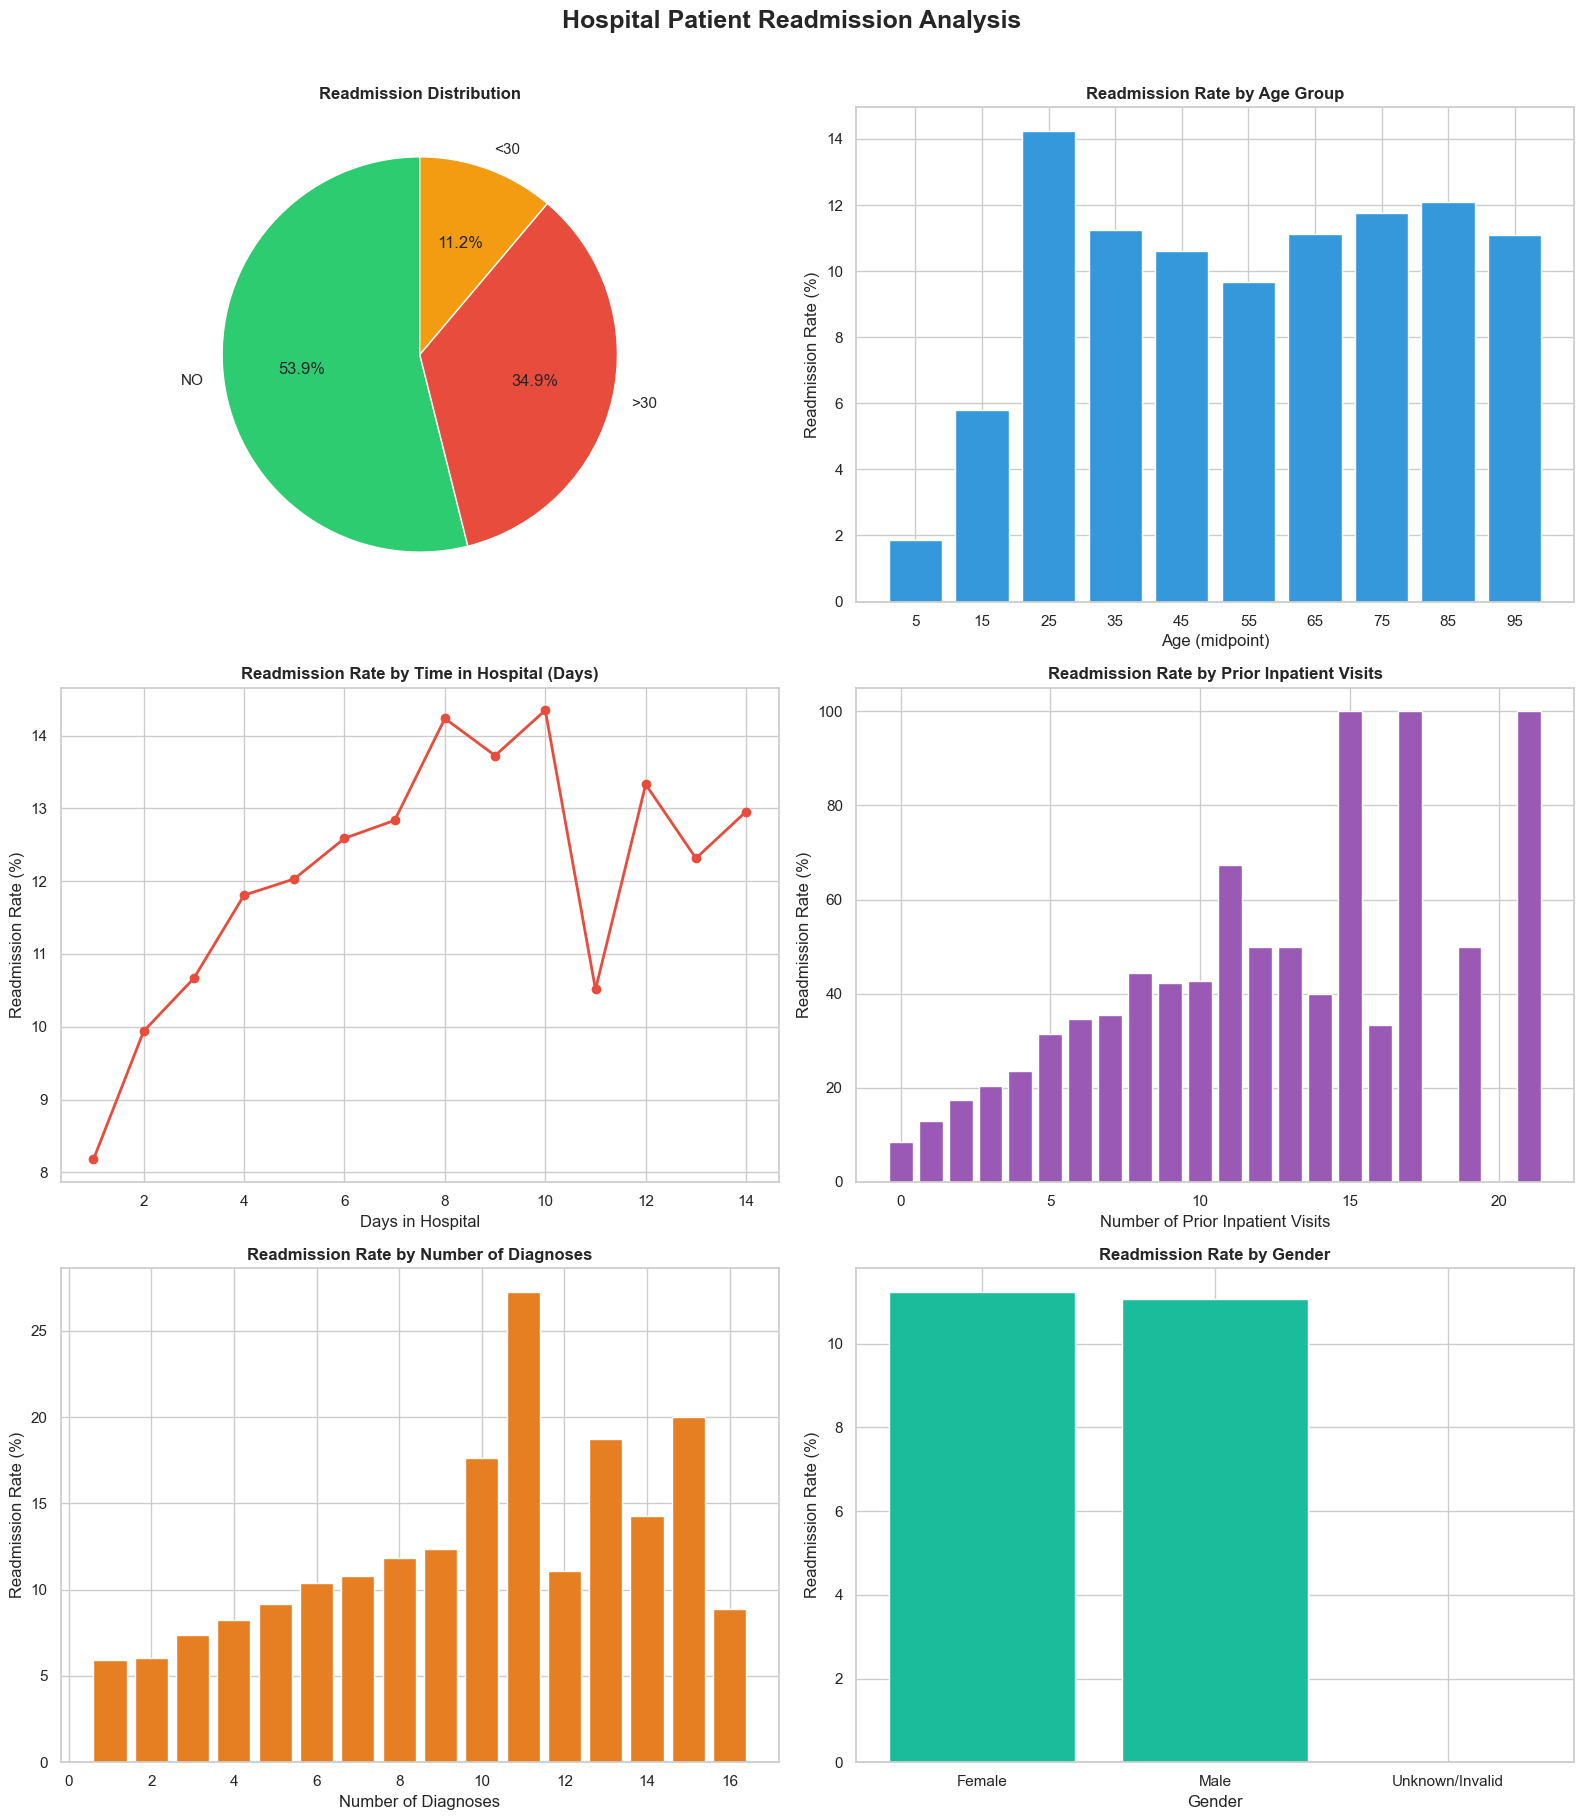

Charts saved!


In [18]:
# ============================================================
# Phase 4: Exploratory Visualizations
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Hospital Patient Readmission Analysis', fontsize=18, fontweight='bold', y=1.01)

# --- 1. Readmission Distribution (Pie Chart) ---
readmit_counts = df['readmitted'].value_counts()
axes[0, 0].pie(readmit_counts, labels=readmit_counts.index, autopct='%1.1f%%',
               colors=['#2ecc71', '#e74c3c', '#f39c12'], startangle=90)
axes[0, 0].set_title('Readmission Distribution', fontweight='bold')

# --- 2. Readmission Rate by Age Group ---
age_readmit = df.groupby('age')['readmitted_binary'].mean() * 100
axes[0, 1].bar(age_readmit.index.astype(str), age_readmit.values, color='#3498db', edgecolor='white')
axes[0, 1].set_title('Readmission Rate by Age Group', fontweight='bold')
axes[0, 1].set_xlabel('Age (midpoint)')
axes[0, 1].set_ylabel('Readmission Rate (%)')

# --- 3. Readmission Rate by Time in Hospital ---
time_readmit = df.groupby('time_in_hospital')['readmitted_binary'].mean() * 100
axes[1, 0].plot(time_readmit.index, time_readmit.values, marker='o', color='#e74c3c', linewidth=2)
axes[1, 0].set_title('Readmission Rate by Time in Hospital (Days)', fontweight='bold')
axes[1, 0].set_xlabel('Days in Hospital')
axes[1, 0].set_ylabel('Readmission Rate (%)')

# --- 4. Number of Inpatient Visits vs Readmission ---
inpatient_readmit = df.groupby('number_inpatient')['readmitted_binary'].mean() * 100
axes[1, 1].bar(inpatient_readmit.index, inpatient_readmit.values, color='#9b59b6', edgecolor='white')
axes[1, 1].set_title('Readmission Rate by Prior Inpatient Visits', fontweight='bold')
axes[1, 1].set_xlabel('Number of Prior Inpatient Visits')
axes[1, 1].set_ylabel('Readmission Rate (%)')

# --- 5. Readmission Rate by Number of Diagnoses ---
diag_readmit = df.groupby('number_diagnoses')['readmitted_binary'].mean() * 100
axes[2, 0].bar(diag_readmit.index, diag_readmit.values, color='#e67e22', edgecolor='white')
axes[2, 0].set_title('Readmission Rate by Number of Diagnoses', fontweight='bold')
axes[2, 0].set_xlabel('Number of Diagnoses')
axes[2, 0].set_ylabel('Readmission Rate (%)')

# --- 6. Gender vs Readmission ---
gender_readmit = df.groupby('gender')['readmitted_binary'].mean() * 100
axes[2, 1].bar(gender_readmit.index, gender_readmit.values, color='#1abc9c', edgecolor='white')
axes[2, 1].set_title('Readmission Rate by Gender', fontweight='bold')
axes[2, 1].set_xlabel('Gender')
axes[2, 1].set_ylabel('Readmission Rate (%)')

plt.tight_layout()
plt.savefig('readmission_eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved!")

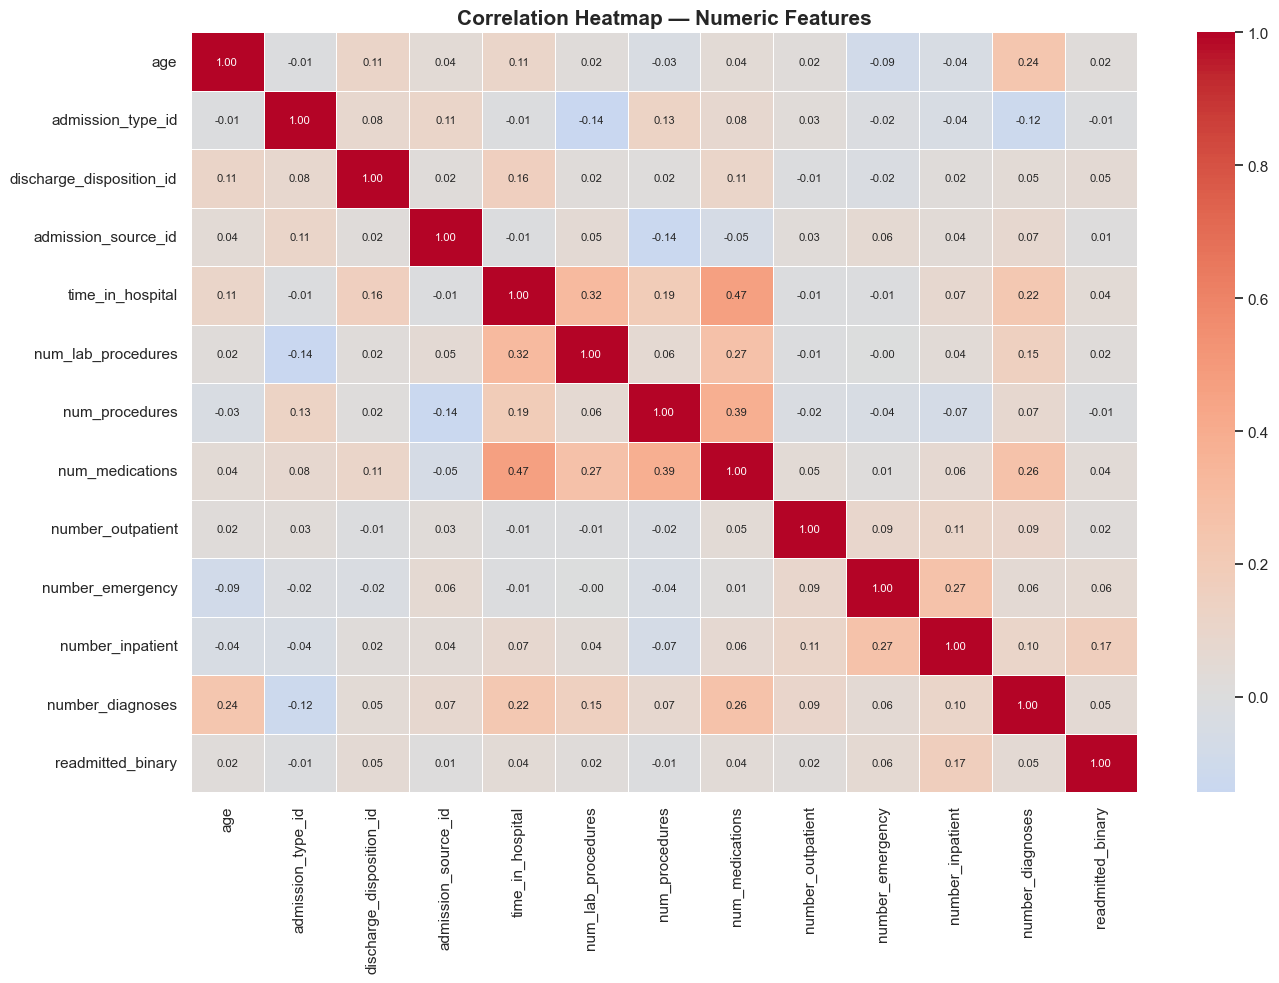


=== Top Features Correlated with Readmission ===
number_inpatient            0.165147
number_emergency            0.060747
discharge_disposition_id    0.050560
number_diagnoses            0.049524
time_in_hospital            0.044199
num_medications             0.038432
num_lab_procedures          0.020364
number_outpatient           0.018893
age                         0.017634
admission_source_id         0.005820
Name: readmitted_binary, dtype: float64


In [19]:
# ============================================================
# Phase 5: Correlation Heatmap
# ============================================================

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation with target
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title('Correlation Heatmap — Numeric Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Top features correlated with readmission ---
print("\n=== Top Features Correlated with Readmission ===")
print(corr_matrix['readmitted_binary'].drop('readmitted_binary').sort_values(ascending=False).head(10))

In [21]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 5.6 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.1 MB 6.2 MB/s eta 0:00:01
   ------------------ --------------------- 3.7/8.1 MB 6.4 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.1 MB 6.1 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.1 MB 6.1 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 6.1 MB/s  0:00:01
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   - -------------------------------------- 1.3/36.6 MB 6.1 MB/s eta 0:00:06
   -- ------------------------------------- 2.6/36.6 MB 6.6 MB/s eta 0:00:06
   --- ------------------------------------ 2.9/36.6 MB 6.4 MB/s eta 0:00:06
   --- ------------------------------------ 3.1/36.6 MB 4.3 MB/s eta 0:00:08
   --- -----------------


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\ammar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [22]:
# ============================================================
# Phase 6: Feature Engineering & Model Preparation
# ============================================================

from sklearn.preprocessing import LabelEncoder

# --- Encode categorical columns ---
cat_cols = ['race', 'gender', 'change', 'diabetesMed', 'insulin',
            'metformin', 'readmitted']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# --- Define features and target ---
drop_cols = ['readmitted', 'readmitted_binary', 'diag_1', 'diag_2', 'diag_3']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df['readmitted_binary']

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())
print("\nFeature columns:\n", X.columns.tolist())

Features shape: (101766, 39)
Target distribution:
 readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

Feature columns:
 ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [24]:
# Find columns that still have string/object values
string_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
print("Columns still as strings:", string_cols)

Columns still as strings: ['repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode ALL remaining string columns in X
for col in string_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print("Done! Remaining string columns:", X.select_dtypes(include=['object', 'string']).columns.tolist())
print("Shape:", X.shape)

Done! Remaining string columns: []
Shape: (101766, 39)


Train size: (81412, 39)
Test size: (20354, 39)

=== Classification Report ===
                precision    recall  f1-score   support

Not Readmitted       0.92      0.69      0.79     18083
Readmitted <30       0.17      0.51      0.26      2271

      accuracy                           0.67     20354
     macro avg       0.55      0.60      0.52     20354
  weighted avg       0.84      0.67      0.73     20354

ROC-AUC Score: 0.6464


<Figure size 600x500 with 0 Axes>

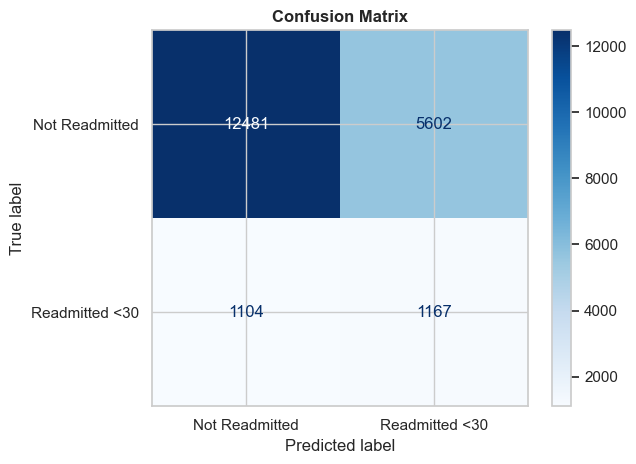

In [31]:
# ============================================================
# Phase 7: Train Logistic Regression Model
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, ConfusionMatrixDisplay)

# --- Split data ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# --- Scale features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Train model (class_weight handles imbalance) ---
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# --- Predictions ---
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# --- Evaluation ---
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Not Readmitted', 'Readmitted <30']))

print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 4))

# --- Confusion Matrix ---
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, 
    display_labels=['Not Readmitted', 'Readmitted <30'],
    cmap='Blues')
plt.title('Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

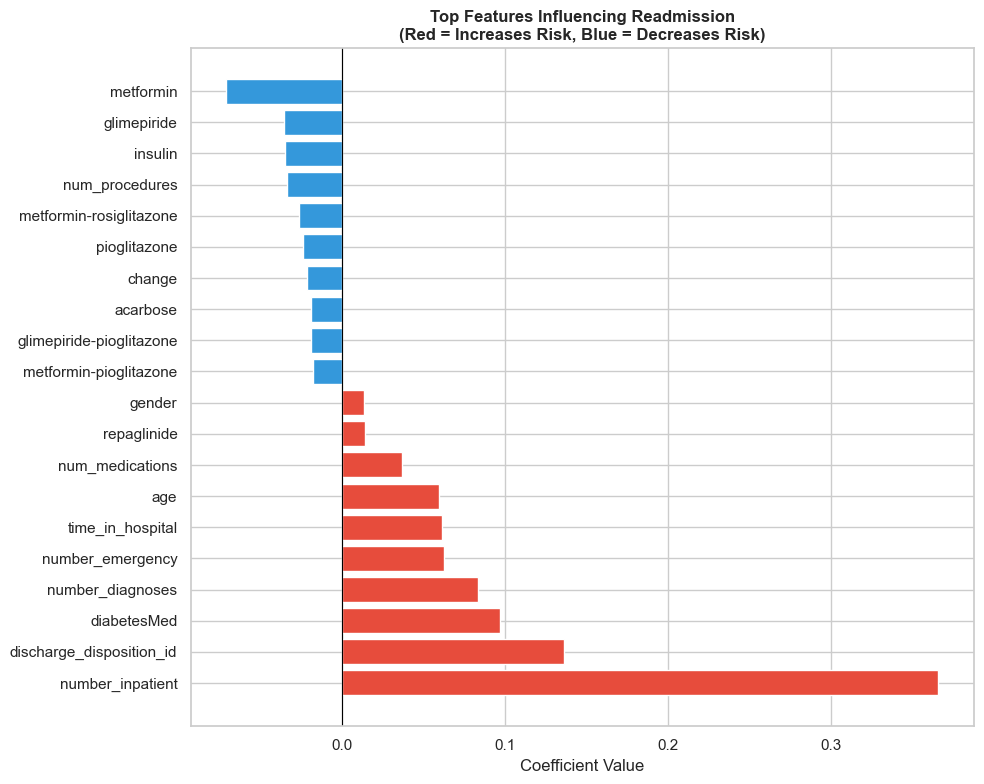


=== Top 10 Risk-Increasing Features ===
                 Feature  Coefficient
        number_inpatient     0.365966
discharge_disposition_id     0.136418
             diabetesMed     0.096918
        number_diagnoses     0.083896
        number_emergency     0.062997
        time_in_hospital     0.061532
                     age     0.059955
         num_medications     0.036827
             repaglinide     0.014316
                  gender     0.013865


In [32]:
# ============================================================
# Phase 8: Feature Importance
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Get coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

# Top 10 most influential features
top_features = pd.concat([coef_df.head(10), coef_df.tail(10)])

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top Features Influencing Readmission\n(Red = Increases Risk, Blue = Decreases Risk)',
          fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Top 10 Risk-Increasing Features ===")
print(coef_df.head(10).to_string(index=False))

In [33]:
# Export cleaned data for Tableau
df.to_csv('hospital_readmission_cleaned.csv', index=False)

# Also export a summary table for dashboard KPIs
kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Patients',
        'Readmitted <30 Days',
        'Not Readmitted',
        'Readmission Rate (%)',
        'ROC-AUC Score',
        'Model Recall (Readmitted)'
    ],
    'Value': [
        len(df),
        df['readmitted_binary'].sum(),
        (df['readmitted_binary'] == 0).sum(),
        round(df['readmitted_binary'].mean() * 100, 2),
        64.64,
        51.0
    ]
})
kpi_summary.to_csv('kpi_summary.csv', index=False)

print("Files exported!")

Files exported!


In [34]:
# Export cleaned data for Tableau
df.to_csv('cleaned_diabetes_data.csv', index=False)
print("File saved!")

File saved!
